# 이슈

호텔 관리인으로서 예약 취소와 관련이 있는 요소들을 파악해보고, 예약 취소율을 줄이기 위한 아이디어 고안

# 데이터 불러오기 및 데이터 확인

데이터 불러오기

In [ ]:
import pandas as pd
df = pd.read_csv("hotel_data_modified.csv")
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,C,3,NaN,NaN,0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,C,4,NaN,NaN,0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,A,C,0,NaN,NaN,0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,A,0,304.0,NaN,0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,A,0,240.0,NaN,0,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,A,A,0,394.0,NaN,0,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,E,E,0,9.0,NaN,0,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,D,D,0,9.0,NaN,0,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,A,A,0,89.0,NaN,0,0,0,Check-Out,2017-09-07


데이터프레임 형식 확인

In [ ]:
df.shape

(119390, 29)

데이터프레임 타입 확인

In [ ]:
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


날짜 데이터 object에서 datetime으로 타입 변경

In [ ]:
df['reservation_status_date'].as type('datetime64[ns]')

,reservation_status_date
0,2015-07-01
1,2015-07-01
2,2015-07-02
3,2015-07-02
4,2015-07-03
...,...
119385,2017-09-06
119386,2017-09-07
119387,2017-09-07
119388,2017-09-07


# 데이터 프레임 통계 요약

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,8.000000,5.000000


#호텔 예약 취소 데이터만 비율(%)로 전환

현재 호텔 예약 취소율은 37.0416%로 확인됌

In [ ]:
df['is_canceled'].value_counts()

,count
is_canceled,
0,75166
1,44224


In [ ]:
df['is_canceled'].value_counts(normalize=True)

,proportion
is_canceled,
0,0.629584
1,0.370416


# 예약취소 변수가 다른 나머지 변수(수치형)들과의 상관관계 파악

In [ ]:
target_corr = df.select_dtypes(include='number').corr()["is_canceled"]
print(target_corr)

is_canceled                       1.000000
lead_time                         0.293123
arrival_date_year                 0.016660
arrival_date_week_number          0.008148
arrival_date_day_of_month        -0.006130
stays_in_weekend_nights          -0.001791
stays_in_week_nights              0.024765
adults                            0.060017
children                          0.005048
babies                           -0.032491
is_repeated_guest                -0.084793
previous_cancellations            0.110133
previous_bookings_not_canceled   -0.057358
booking_changes                  -0.144381
agent                            -0.083114
company                          -0.020642
days_in_waiting_list              0.054186
required_car_parking_spaces      -0.195498
total_of_special_requests        -0.234658
Name: is_canceled, dtype: float64


#예약 취소율과 상관관계가 가장 깊은 변수

하기 5개의 변수가 예약 취소율과 상관관계가 가장 깊음


1.   lead_time
2.   total_of_special_requests
3.   required_car_parking_spaces
4.   booking_changes
5.   previous_cancellations



In [ ]:
df.select_dtypes(include='number').corr()["is_canceled"].abs().sort_values(ascending=False)

,is_canceled
is_canceled,1.000000
lead_time,0.293123
total_of_special_requests,0.234658
required_car_parking_spaces,0.195498
booking_changes,0.144381
previous_cancellations,0.110133
is_repeated_guest,0.084793
agent,0.083114
adults,0.060017
previous_bookings_not_canceled,0.057358


상관관계가 가장 깊은 변수들을 예약 취소율의 데이터프레임으로 변환

In [ ]:
new_cols = ["lead_time", "total_of_special_requests", "required_car_parking_spaces",
               "booking_changes", "previous_cancellations"]

df[new_cols + ["is_canceled"]].corr(numeric_only=True)[["is_canceled"]]


,is_canceled
lead_time,0.293123
total_of_special_requests,-0.234658
required_car_parking_spaces,-0.195498
booking_changes,-0.144381
previous_cancellations,0.110133
is_canceled,1.000000


#데이터 시각화



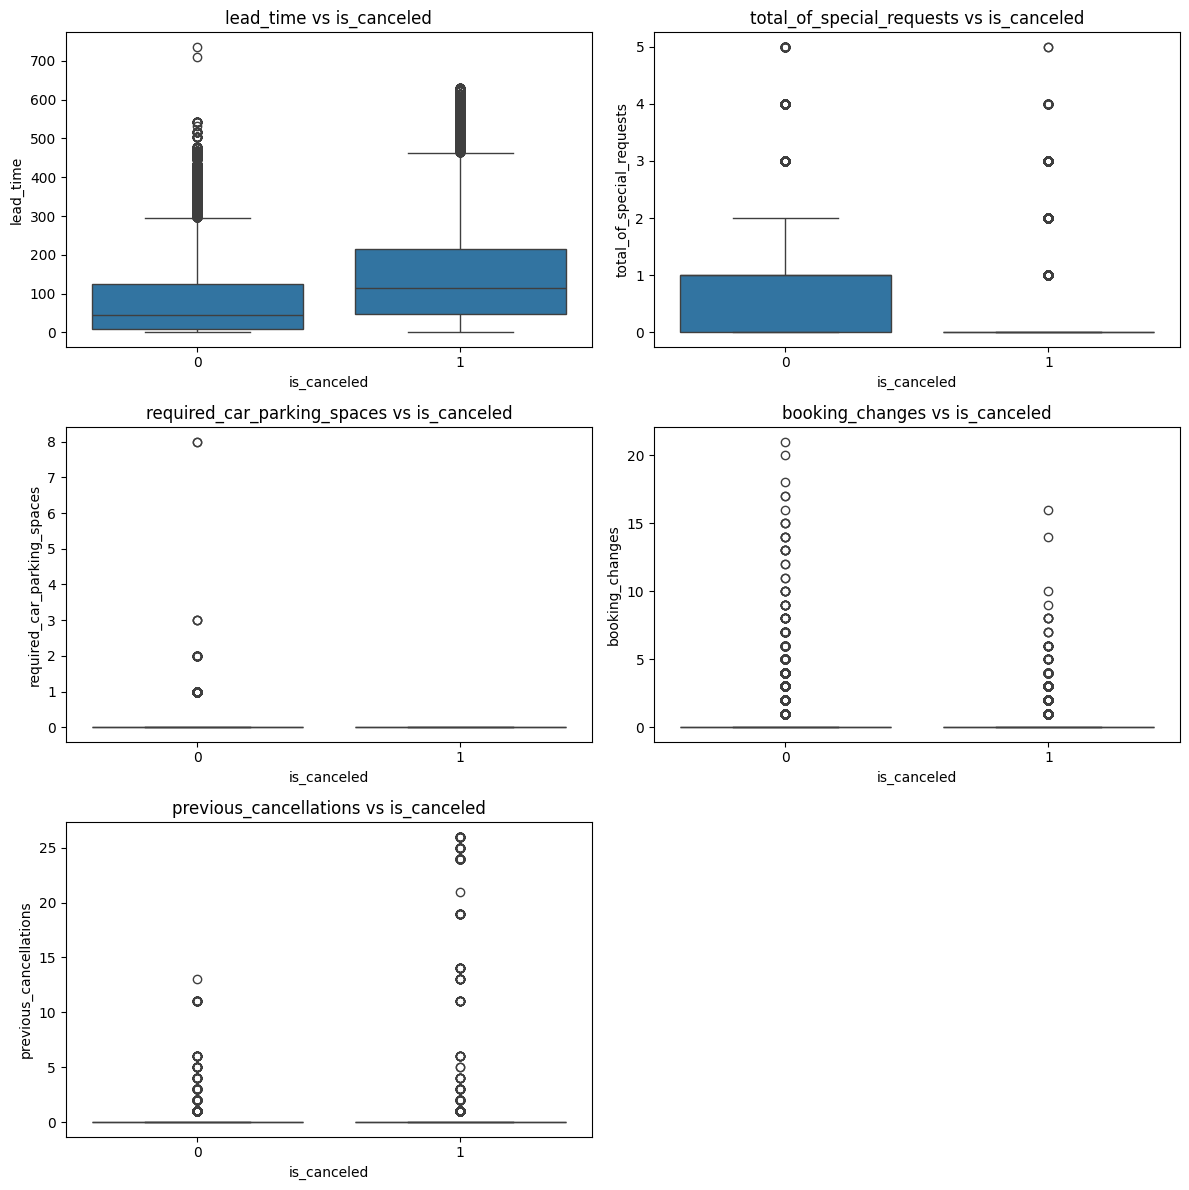

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

axes = axes.flatten()

for i, col in enumerate(new_cols):
    sns.boxplot(
        x="is_canceled",
        y=col,
        data=df,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs is_canceled")

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

#예약 취소율과 변수들과의 상관관계 해석

1. lead_time변수

예약을 취소하지 않은(0) 그룹의 중간값은 30~40 사이

예약을 취소한 그룹(1)의 중간값은 100 부근

이는 **lead_time이 클수록 예약 취소 가능성이 높음**을 확인 가능

2. total_of_speical_request 변수

예약을 취소하지 않은 그룹(0)의 중간값은 0~1 사이

예약을 취소한 그룹(1)의 중간값은 거의 0에 수렵

이는 **total_of_speical_request가 작을 수록 예약 취소 가능성이 높음**을 확인 가능

3. required_car_parking_spaces 변수

예약을 취소하지 않은 그룹(0)의 요청한 주차공간은 존재

예약을 취소한 그룹(1)의 요청한 주차공간 X

이는 **required_car_parking_spaces가 확보되면 예약 취소 가능성 낮음** 확인

4. booking_change 변수

예약을 취소하지 않은 그룹(0)의 예약 변경 횟수는 많음

예약을 취소한 그룹(1)의 예약 변경 횟수는 적음

이는 **booking_change 클수록 예약 취소 감소 가능성 낮음**

5. previous_cancellations 변수

예약을 취소하지 않은 그룹(0)의 현재 예약 이전 고객이 취소한 예약 수는 적음

예약을 취소한 그룹(1)의 현재 예약 이전 고객이 취소한 예약 수는 많음

이는 **previous_cancellations 클수록 예약 취소 가능성 높음**

# 변수들의 예약 취소율 그래프

lead_time 변수의 예약 취소율

/tmp/ipython-input-3284343077.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("lead_time_bin")["is_canceled"]


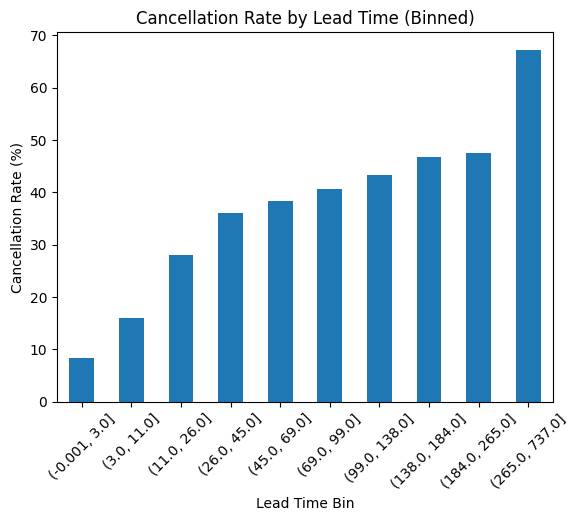

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 분석 변수
new_cols = [
    "lead_time",
    "total_of_special_requests",
    "required_car_parking_spaces",
    "booking_changes",
    "previous_cancellations"
]


df["lead_time_bin"] = pd.qcut(df["lead_time"], 10, duplicates="drop")

lead_cancel_rate = (
    df.groupby("lead_time_bin")["is_canceled"]
    .mean()*100
)

plt.figure()
lead_cancel_rate.plot(kind="bar")
plt.title("Cancellation Rate by Lead Time (Binned)")
plt.xlabel("Lead Time Bin")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

lead_time의 예약 취소율은 우상향 하는 중

가장 많이 취소율이 발생한 구간은 265일부터 737일 사이로 약 67%

138일~265일은 48%

total_of_special_requests 변수의 예약 취소율

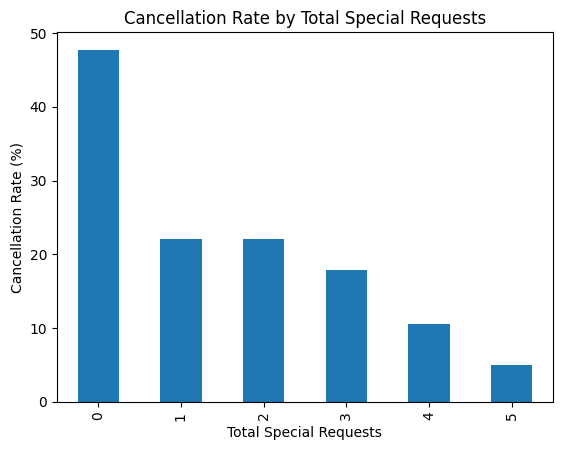

In [ ]:
import matplotlib.pyplot as plt

special_cancel_rate = df.groupby("total_of_special_requests")["is_canceled"].mean()*100

plt.figure()
special_cancel_rate.plot(kind="bar")
plt.title("Cancellation Rate by Total Special Requests")
plt.xlabel("Total Special Requests")
plt.ylabel("Cancellation Rate (%)")
plt.show()

total_of_special_requests 변수는 우하향 하는 중

특별 요청이 없을 때 예약 취소율 약 48%

특별 요청이 1 ~ 2개일 때 예약 취소율 약 22%

특별 요청이 4 ~ 5개일 때 예약 취소율 5~10%

required_car_parking_spaces 변수의 예약 취소율

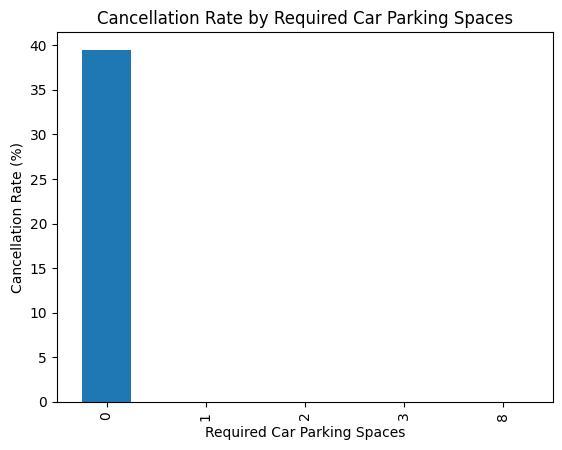

In [ ]:
import matplotlib.pyplot as plt

parking_cancel_rate = df.groupby("required_car_parking_spaces")["is_canceled"].mean()*100

plt.figure()
parking_cancel_rate.plot(kind="bar")
plt.title("Cancellation Rate by Required Car Parking Spaces")
plt.xlabel("Required Car Parking Spaces")
plt.ylabel("Cancellation Rate (%)")
plt.show()

required_car_parking_spaces 변수

요청한 주차공간이 0일 때 취소율 40%

1대 이상부터는 0%

booking_changes 변수의 예약 취소율

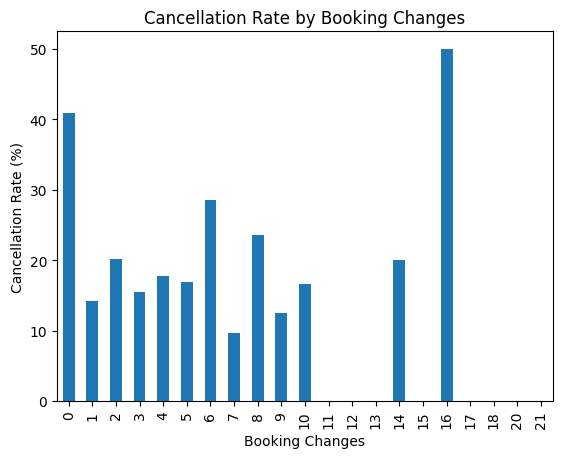

In [ ]:
import matplotlib.pyplot as plt

booking_cancel_rate = df.groupby("booking_changes")["is_canceled"].mean()*100

plt.figure()
booking_cancel_rate.plot(kind="bar")
plt.title("Cancellation Rate by Booking Changes")
plt.xlabel("Booking Changes")
plt.ylabel("Cancellation Rate (%)")
plt.show()

booking_change 변수

예약을 바꾸지 않았을 때 취소율 40%

1~5번 예약 변경 시 취소율 감소

다만 일부 극단값에서 값이 튐

예약을 수정할 사람일수록 투숙 가능성 높음

previous_cancellations 변수의 예약 취소율

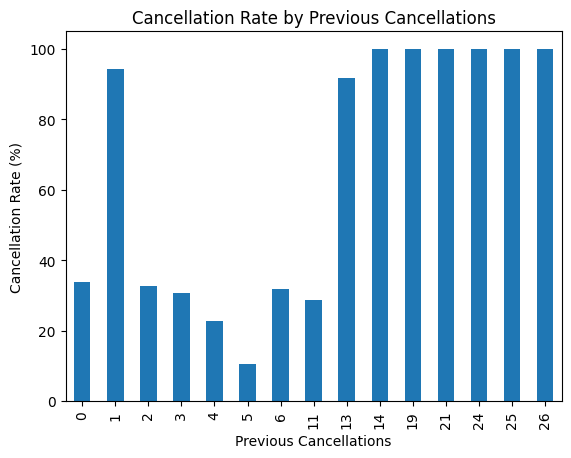

In [ ]:
import matplotlib.pyplot as plt

previous_cancel_rate = df.groupby("previous_cancellations")["is_canceled"].mean()*100

plt.figure()
previous_cancel_rate.plot(kind="bar")
plt.title("Cancellation Rate by Previous Cancellations")
plt.xlabel("Previous Cancellations")
plt.ylabel("Cancellation Rate (%)")
plt.show()

previous_cancellations 변수

현재 예약 이전 예약 취소 수가 0일 때 취소율 34%

1회 : 약 95%

13회 이상 : 거의 100%

과거 취소 이력이 많을 수록 취소확률 100%

# 이슈 해결방안


# 1. lead_time

0 ~ 30 : 일반 정책

30 ~ 120일 : 리마인드 메일 전송

120 이후 : 부분 선결제 및 취소 수수료 증가

# 2. total_of_special_requests

예약 직후 고객 특별 요청 사항 확인

# 3. required_car_parking_spaces

- 주차 패키지 상품 출시

- 렌터카 연계 할인

# 4. booking_changes

- 예약변경 프로세스 간소화

- 일정변경 강조


# 5. previous_cancellations

- 1회 이상 : 선결제 필수
- 3회 이상 : 취소 수수료 강화
- 5회 이상 : 일부 혜택 이용 금지